## Import Dataset

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [37]:
df = pd.read_csv(r"D:\Downloads\Datasets\kaggle_survey_2017_2021.csv", low_memory=False)

In [38]:
df

,-,Time from Start to Finish (seconds),Q1,Q2,Q3,Q4,Q5,Q6,Q7_Part_1,Q7_Part_2,...,Q38_B_Part_1,Q38_B_Part_2,Q38_B_Part_3,Q38_B_Part_4,Q38_B_Part_5,Q38_B_Part_6,Q38_B_Part_7,Q38_B_Part_9,Q38_B_Part_11,Q38_B_OTHER
0,Year,Duration (in seconds),What is your age (# years)?,What is your gender? - Selected Choice,In which country do you currently reside?,What is the highest level of formal education ...,Select the title most similar to your current ...,For how many years have you been writing code ...,What programming languages do you use on a reg...,What programming languages do you use on a reg...,...,"In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor...","In the next 2 years, do you hope to become mor..."
1,2021,910,50-54,Man,India,Bachelorâ€™s degree,Other,5-10 years,Python,R,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2021,784,50-54,Man,Indonesia,Masterâ€™s degree,Program/Project Manager,20+ years,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2021,924,22-24,Man,Pakistan,Masterâ€™s degree,Software Engineer,1-3 years,Python,NaN,...,NaN,NaN,NaN,NaN,TensorBoard,NaN,NaN,NaN,NaN,NaN
4,2021,575,45-49,Man,Mexico,Doctoral degree,Research Scientist,20+ years,Python,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
106297,2017,NaN,22-24,Female,Other,Master's degree,NaN,Less than a year,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
106298,2017,NaN,25-29,Male,Indonesia,Bachelor's degree,Programmer,1 to 2 years,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
106299,2017,NaN,25-29,Female,Taiwan,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
106300,2017,NaN,NaN,Female,Singapore,I prefer not to answer,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Explore the Data 

In [57]:
#Temporarily Viewed:


#print(df.columns.tolist())               #See all column names in a list
#questions = df.iloc[0]                   # Grab the first row (the questions) before we start cleaning


#for col, question in questions.items():
    #print(f"{col}: {question}")

### Rename Columns

In [41]:
core_columns = {
    'Time from Start to Finish (seconds)': 'duration',
    'Q1': 'age',
    'Q2': 'gender',
    'Q3': 'country',
    'Q4': 'education',
    'Q5': 'job_title',
    'Q6': 'coding_experience',
    'Q8': 'recommended_language',
    'Q15': 'ml_experience',
    'Q20': 'industry',
    'Q25': 'salary',
    'Q41': 'primary_tool'
}

df.rename(columns=core_columns, inplace=True)


### Keep Needed columns only 

In [42]:
current_core_names = list(core_columns.values())
tool_cols = [col for col in df.columns if col.startswith(('Q7_Part', 'Q9_Part', 'Q14_Part'))]
# Reframe dataset

analysis_df = df[current_core_names + tool_cols].copy()
if analysis_df.iloc[0]['age'] == 'What is your age (# years)?':
    analysis_df = analysis_df.drop(0)

analysis_df.head()

,duration,age,gender,country,education,job_title,coding_experience,recommended_language,ml_experience,industry,...,Q14_Part_2,Q14_Part_3,Q14_Part_4,Q14_Part_5,Q14_Part_6,Q14_Part_7,Q14_Part_8,Q14_Part_9,Q14_Part_10,Q14_Part_11
1,910,50-54,Man,India,Bachelorâ€™s degree,Other,5-10 years,Python,5-10 years,Manufacturing/Fabrication,...,Seaborn,NaN,Ggplot / ggplot2,Shiny,NaN,NaN,NaN,NaN,Leaflet / Folium,NaN
2,784,50-54,Man,Indonesia,Masterâ€™s degree,Program/Project Manager,20+ years,Python,Under 1 year,Manufacturing/Fabrication,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,924,22-24,Man,Pakistan,Masterâ€™s degree,Software Engineer,1-3 years,Python,I do not use machine learning methods,Academics/Education,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,575,45-49,Man,Mexico,Doctoral degree,Research Scientist,20+ years,Python,5-10 years,Academics/Education,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,781,45-49,Man,India,Doctoral degree,Other,< 1 years,Python,10-20 years,Academics/Education,...,Seaborn,NaN,Ggplot / ggplot2,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Clean the Data

In [43]:
analysis_df['education'] = analysis_df['education'].str.replace('â€™', "'", regex=False)
analysis_df['job_title'] = analysis_df['job_title'].str.replace('â€™', "'", regex=False)   #Fix encoding for Education and Job Titles


for col in tool_cols:
    analysis_df[col] = analysis_df[col].notna().astype(int)                 #Convert Tool columns to Binary (1 for used, 0 for not)

### Label Handling 

In [44]:
le = LabelEncoder()
analysis_df['job_title_encoded'] = le.fit_transform(analysis_df['job_title'].astype(str))


mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Job Title Mapping:", mapping)           # Show the mapping for reference

Job Title Mapping: {'Business Analyst': np.int64(0), 'Chief Officer': np.int64(1), 'Computer Scientist': np.int64(2), 'Consultant': np.int64(3), 'Currently not employed': np.int64(4), 'DBA/Database Engineer': np.int64(5), 'Data Analyst': np.int64(6), 'Data Engineer': np.int64(7), 'Data Journalist': np.int64(8), 'Data Miner': np.int64(9), 'Data Scientist': np.int64(10), 'Developer Advocate': np.int64(11), 'Developer Relations/Advocacy': np.int64(12), 'Engineer': np.int64(13), 'Machine Learning Engineer': np.int64(14), 'Manager': np.int64(15), 'Marketing Analyst': np.int64(16), 'Not employed': np.int64(17), 'Operations Research Practitioner': np.int64(18), 'Other': np.int64(19), 'Predictive Modeler': np.int64(20), 'Principal Investigator': np.int64(21), 'Product Manager': np.int64(22), 'Product/Project Manager': np.int64(23), 'Program/Project Manager': np.int64(24), 'Programmer': np.int64(25), 'Research Assistant': np.int64(26), 'Research Scientist': np.int64(27), 'Researcher': np.int64(

### Insights

#### Explore the insights from Data

In [45]:
edu_map = {
    "No formal education past high school": 1,
    "Some college/university study without earning a bachelor's degree": 2,
    "Bachelor's degree": 3,
    "Master's degree": 4,
    "Doctoral degree": 5,
    "Professional doctorate": 6,
    "I prefer not to answer": 0
}
analysis_df['edu_rank'] = analysis_df['education'].map(edu_map).fillna(0)

# B. Label Encoding for Nominal Variables (Job Title & Gender)
le = LabelEncoder()
analysis_df['job_title_encoded'] = le.fit_transform(analysis_df['job_title'].astype(str))
analysis_df['gender_encoded'] = le.fit_transform(analysis_df['gender'].astype(str))

print("Categorical variables have been encoded for ML.")

Categorical variables have been encoded for ML.


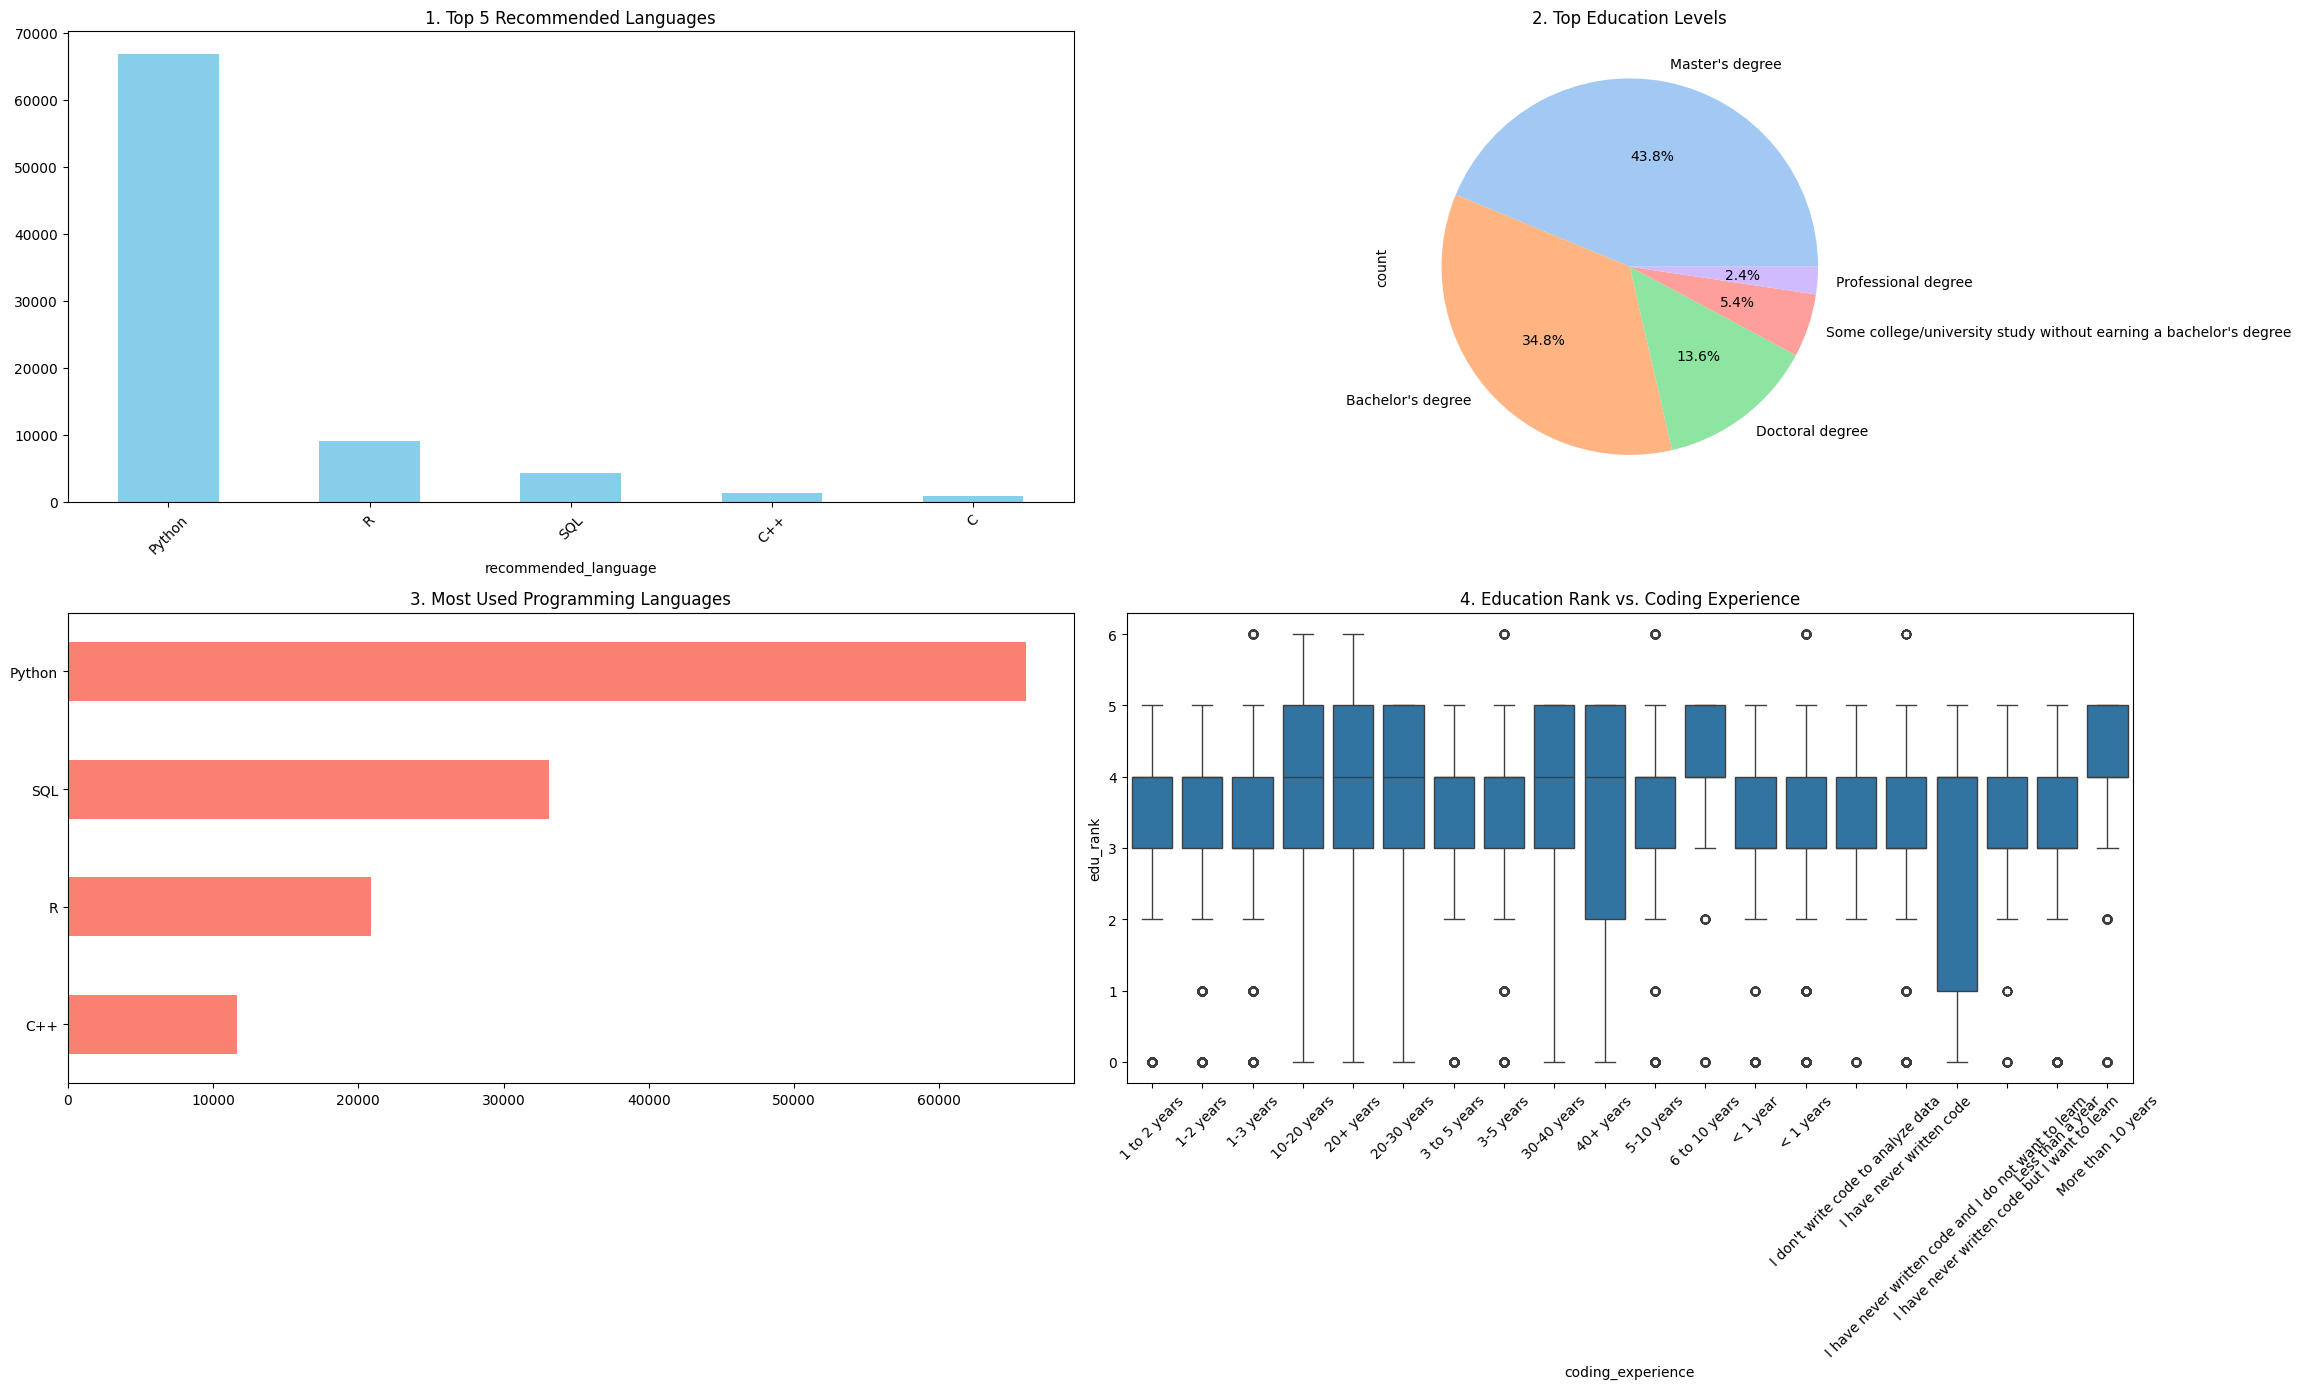

In [47]:
plt.figure(figsize=(24, 14))

#Top Recommended Languages
plt.subplot(2, 2, 1)
analysis_df['recommended_language'].value_counts().head(5).plot(kind='bar', color='skyblue')
plt.title('1. Top 5 Recommended Languages')
plt.xticks(rotation=45)

#Education Level Distribution
plt.subplot(2, 2, 2)
analysis_df['education'].value_counts().head(5).plot(kind='pie', autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('2. Top Education Levels')

#Language Usage (Binary tool columns)
plt.subplot(2, 2, 3)
lang_usage = {
    'Python': analysis_df['Q7_Part_1'].sum(),
    'R': analysis_df['Q7_Part_2'].sum(),
    'SQL': analysis_df['Q7_Part_3'].sum(),
    'C++': analysis_df['Q7_Part_5'].sum()
}
pd.Series(lang_usage).sort_values().plot(kind='barh', color='salmon')
plt.title('3. Most Used Programming Languages')

#Experience vs Education Rank
plt.subplot(2, 2, 4)
sns.boxplot(x='coding_experience', y='edu_rank', data=analysis_df.sort_values('coding_experience'))
plt.title('4. Education Rank vs. Coding Experience')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()